# Monte Carlo Simulation for Project Portfolio Prioritization

This notebook applies Monte Carlo simulation to evaluate the uncertainty of project scores and assess the robustness of the portfolio prioritization.

## 1. Objective

The objective of this analysis is to evaluate how uncertainty in project evaluation criteria affects project prioritization.

Monte Carlo simulation is used to generate multiple possible scenarios for each project and estimate the distribution of its overall score.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

## 2. Load the Dataset

The project dataset is loaded from the raw data directory.

In [2]:
df = pd.read_csv("../data/raw/projects.csv")

df.shape

(4000, 51)

## 3. Define Evaluation Criteria

The Monte Carlo simulation uses the same criteria and objectives defined in the AHP analysis.

In [3]:
criteria_objectives = {
    "Project_Budget_USD": "min",
    "Estimated_Timeline_Months": "min",
    "Complexity_Score": "min",
    "Previous_Delivery_Success_Rate": "max",
    "Resource_Availability": "max",
    "Historical_Risk_Incidents": "min",
}

criteria_names = list(criteria_objectives.keys())

criteria_names

['Project_Budget_USD',
 'Estimated_Timeline_Months',
 'Complexity_Score',
 'Previous_Delivery_Success_Rate',
 'Resource_Availability',
 'Historical_Risk_Incidents']

## 4. Simulation Parameters

The Monte Carlo simulation generates multiple scenarios for each project.

The number of simulations is set to 100,000 to obtain stable estimates of the score distributions.

In [4]:
N_SIMULATIONS = 100_000
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

## 5. Criterion Statistics

The uncertainty of each criterion is estimated from its observed mean and standard deviation.

These statistics are used to parameterize the probability distributions in the Monte Carlo simulation.

In [5]:
criterion_stats = df[criteria_names].agg(
    ["mean", "std", "min", "max"]
).T

criterion_stats

,mean,std,min,max
Project_Budget_USD,1.143032e+06,590878.115350,159355.55,3768354.37
Estimated_Timeline_Months,1.714775e+01,6.926609,2.00,36.00
Complexity_Score,6.192525e+00,2.212538,1.62,10.00
Previous_Delivery_Success_Rate,7.504375e-01,0.143712,0.15,0.99
Resource_Availability,6.516950e-01,0.201163,0.30,1.00
Historical_Risk_Incidents,1.507250e+00,1.210915,0.00,8.00


## 6. Inspect Criterion Distributions

The empirical distributions of the evaluation criteria are inspected before defining the simulation model.

In [6]:
df[criteria_names].describe()

,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Previous_Delivery_Success_Rate,Resource_Availability,Historical_Risk_Incidents
count,4.000000e+03,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,1.143032e+06,17.147750,6.192525,0.750437,0.651695,1.507250
std,5.908781e+05,6.926609,2.212538,0.143712,0.201163,1.210915
min,1.593555e+05,2.000000,1.620000,0.150000,0.300000,0.000000
25%,6.925329e+05,12.000000,4.460000,0.660000,0.480000,1.000000
50%,1.007472e+06,17.000000,6.015000,0.770000,0.650000,1.000000
75%,1.475870e+06,22.000000,7.862500,0.860000,0.820000,2.000000
max,3.768354e+06,36.000000,10.000000,0.990000,1.000000,8.000000


array([[<Axes: title={'center': 'Project_Budget_USD'}>,
        <Axes: title={'center': 'Estimated_Timeline_Months'}>],
       [<Axes: title={'center': 'Complexity_Score'}>,
        <Axes: title={'center': 'Previous_Delivery_Success_Rate'}>],
       [<Axes: title={'center': 'Resource_Availability'}>,
        <Axes: title={'center': 'Historical_Risk_Incidents'}>]],
      dtype=object)

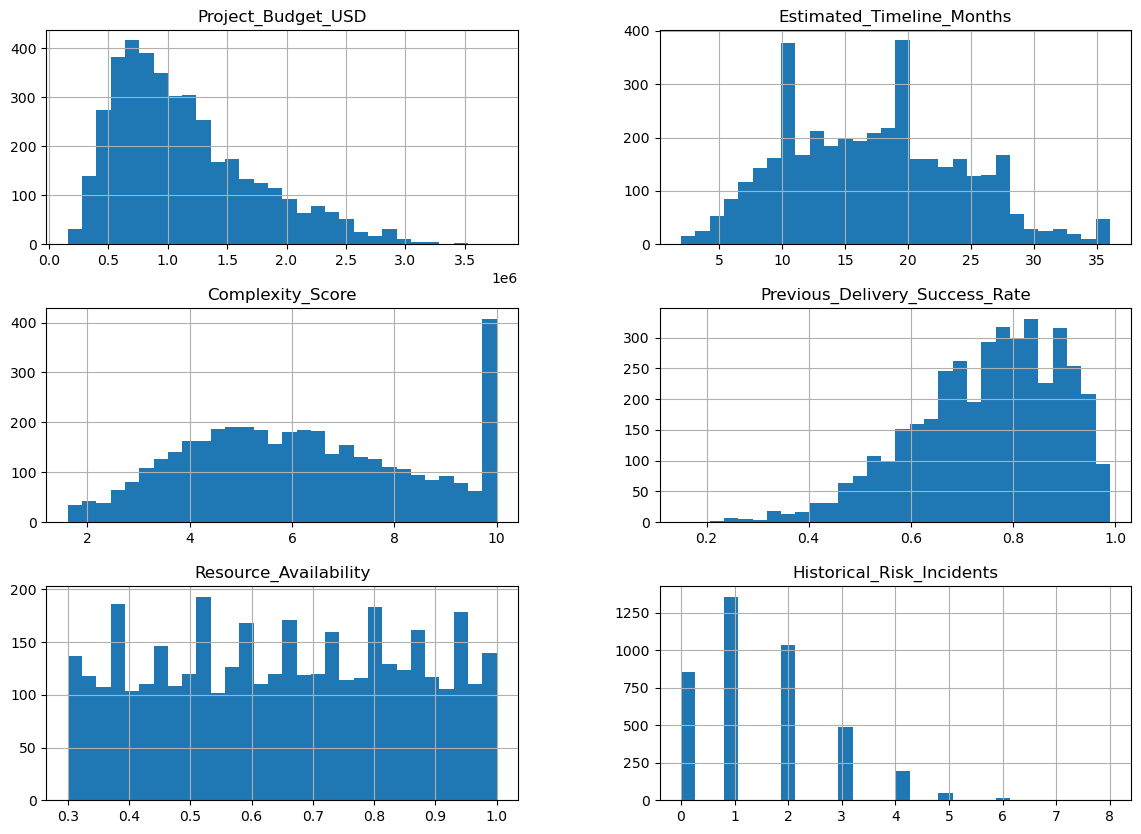

In [7]:
df[criteria_names].hist(
    figsize=(14, 10),
    bins=30
)

## 7. Define the Simulation Distributions

For each criterion, a truncated normal distribution is used to represent uncertainty around the observed project values.

The mean and standard deviation are estimated from the dataset, while the observed minimum and maximum values are used as lower and upper bounds.

In [8]:
from scipy.stats import truncnorm

## 8. Create a Truncated Normal Sampling Function

A reusable function is created to generate random values from a truncated normal distribution while preserving the observed range of each criterion.

In [9]:
def generate_truncated_normal(
    mean,
    std,
    minimum,
    maximum,
    size
):
    """
    Generate random values from a truncated normal distribution.
    """

    lower = (minimum - mean) / std
    upper = (maximum - mean) / std

    return truncnorm.rvs(
        lower,
        upper,
        loc=mean,
        scale=std,
        size=size
    )

## 9. Test the Sampling Function

The sampling function is tested using the project budget criterion before running the full Monte Carlo simulation.

In [10]:
budget_stats = criterion_stats.loc["Project_Budget_USD"]

budget_sample = generate_truncated_normal(
    mean=budget_stats["mean"],
    std=budget_stats["std"],
    minimum=budget_stats["min"],
    maximum=budget_stats["max"],
    size=10_000
)

pd.Series(budget_sample).describe()

count    1.000000e+04
mean     1.193724e+06
std      5.285300e+05
min      1.594211e+05
25%      8.030018e+05
50%      1.168032e+06
75%      1.546191e+06
max      3.185638e+06
dtype: float64

## 10. Generate Monte Carlo Samples

For each evaluation criterion, 100,000 random scenarios are generated from its truncated normal distribution.

Each simulation represents a possible realization of the project portfolio under uncertainty.

In [11]:
simulation_data = {}

for criterion in criteria_names:

    stats = criterion_stats.loc[criterion]

    simulation_data[criterion] = generate_truncated_normal(
        mean=stats["mean"],
        std=stats["std"],
        minimum=stats["min"],
        maximum=stats["max"],
        size=N_SIMULATIONS
    )

simulation_df = pd.DataFrame(simulation_data)

simulation_df.shape

(100000, 6)

## 11. Validate the Simulated Data

The simulated values are compared with the observed statistics to verify whether the generated scenarios remain consistent with the original dataset.

In [12]:
simulation_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Project_Budget_USD,100000.0,1.204553e+06,531783.151336,159386.758768,808557.294640,1.180965e+06,1.564821e+06,3.638795e+06
Estimated_Timeline_Months,100000.0,1.735646e+01,6.540856,2.000891,12.691774,1.726054e+01,2.185101e+01,3.599266e+01
Complexity_Score,100000.0,6.097028e+00,1.888784,1.620101,4.735637,6.134947e+00,7.505392e+00,9.999526e+00
Previous_Delivery_Success_Rate,100000.0,7.350524e-01,0.129749,0.154421,0.647685,7.413519e-01,8.315299e-01,9.899926e-01
Resource_Availability,100000.0,6.514907e-01,0.163887,0.300001,0.528548,6.524615e-01,7.738960e-01,9.999965e-01
Historical_Risk_Incidents,100000.0,1.755244e+00,1.014674,0.000031,0.976338,1.663660e+00,2.423061e+00,6.686016e+00


In [13]:
validation = pd.DataFrame(index=criteria_names)

validation["Observed_Min"] = [
    criterion_stats.loc[c, "min"]
    for c in criteria_names
]

validation["Simulated_Min"] = [
    simulation_df[c].min()
    for c in criteria_names
]

validation["Observed_Max"] = [
    criterion_stats.loc[c, "max"]
    for c in criteria_names
]

validation["Simulated_Max"] = [
    simulation_df[c].max()
    for c in criteria_names
]

validation

,Observed_Min,Simulated_Min,Observed_Max,Simulated_Max
Project_Budget_USD,159355.55,159386.758768,3768354.37,3.638795e+06
Estimated_Timeline_Months,2.00,2.000891,36.00,3.599266e+01
Complexity_Score,1.62,1.620101,10.00,9.999526e+00
Previous_Delivery_Success_Rate,0.15,0.154421,0.99,9.899926e-01
Resource_Availability,0.30,0.300001,1.00,9.999965e-01
Historical_Risk_Incidents,0.00,0.000031,8.00,6.686016e+00


## 12. Normalize the Simulated Criteria

The simulated criterion values are normalized to a common 0–1 scale.

For benefit criteria, higher values receive higher normalized scores. For cost criteria, lower values receive higher normalized scores.

In [14]:
normalized_simulation = simulation_df.copy()

for criterion, objective in criteria_objectives.items():

    minimum = criterion_stats.loc[criterion, "min"]
    maximum = criterion_stats.loc[criterion, "max"]

    if objective == "max":
        normalized_simulation[criterion] = (
            simulation_df[criterion] - minimum
        ) / (maximum - minimum)

    elif objective == "min":
        normalized_simulation[criterion] = (
            maximum - simulation_df[criterion]
        ) / (maximum - minimum)

    else:
        raise ValueError(
            f"Invalid objective: {objective}"
        )

In [15]:
normalized_simulation.describe().T

,count,mean,std,min,25%,50%,75%,max
Project_Budget_USD,100000.0,0.710391,0.147349,0.035899,0.610566,0.716927,0.820116,0.999991
Estimated_Timeline_Months,100000.0,0.548339,0.192378,0.000216,0.416147,0.551160,0.685536,0.999974
Complexity_Score,100000.0,0.465748,0.225392,0.000057,0.297686,0.461224,0.628206,0.999988
Previous_Delivery_Success_Rate,100000.0,0.696491,0.154463,0.005263,0.592483,0.703990,0.811345,0.999991
Resource_Availability,100000.0,0.502130,0.234125,0.000002,0.326497,0.503516,0.676994,0.999995
Historical_Risk_Incidents,100000.0,0.780594,0.126834,0.164248,0.697117,0.792042,0.877958,0.999996


## 13. Apply AHP Weights

The AHP-derived criteria weights are applied to the normalized simulated values.

This connects the Monte Carlo simulation with the previously established decision-maker preferences.

In [16]:
ahp_weights = pd.Series(
    {
        "Project_Budget_USD": 0.0375,
        "Estimated_Timeline_Months": 0.0733,
        "Complexity_Score": 0.1930,
        "Previous_Delivery_Success_Rate": 0.4207,
        "Resource_Availability": 0.0965,
        "Historical_Risk_Incidents": 0.1790,
    }
)

ahp_weights.sum()

1.0

In [17]:
weighted_simulation = normalized_simulation.mul(
    ahp_weights,
    axis=1
)

## 14. Calculate Monte Carlo Scores

For each simulation, a weighted overall score is calculated by combining the normalized criterion values with the AHP weights.

In [18]:
simulation_scores = weighted_simulation.sum(axis=1)

simulation_scores.describe()

count    100000.000000
mean          0.637918
std           0.085584
min           0.267981
25%           0.580763
50%           0.640064
75%           0.697673
max           0.936052
dtype: float64

## 15. Define Project-Level Uncertainty

The Monte Carlo simulation is performed at the project level.

For each project, the observed criterion value is treated as the central estimate, while uncertainty is introduced according to the coefficient of variation observed in the dataset.

The simulated values are constrained to the observed minimum and maximum values of each criterion.

In [19]:
criterion_stats["cv"] = (
    criterion_stats["std"] / criterion_stats["mean"]
)

criterion_stats[["mean", "std", "cv"]]

,mean,std,cv
Project_Budget_USD,1.143032e+06,590878.115350,0.516939
Estimated_Timeline_Months,1.714775e+01,6.926609,0.403937
Complexity_Score,6.192525e+00,2.212538,0.357292
Previous_Delivery_Success_Rate,7.504375e-01,0.143712,0.191504
Resource_Availability,6.516950e-01,0.201163,0.308677
Historical_Risk_Incidents,1.507250e+00,1.210915,0.803393


## 16. Create the Project Simulation Function

A function is created to simulate the overall score of an individual project.

For each criterion, random values are generated around the project's observed value using a normal distribution whose standard deviation is determined by the criterion's coefficient of variation.

In [20]:
def simulate_project_score(
    project,
    criteria_stats,
    weights,
    objectives,
    n_simulations=100_000
):
    """
    Simulate the score distribution of a single project.
    """

    simulated_values = {}

    for criterion in criteria_names:

        observed_value = project[criterion]
        cv = criteria_stats.loc[criterion, "cv"]

        minimum = criteria_stats.loc[criterion, "min"]
        maximum = criteria_stats.loc[criterion, "max"]

        std = abs(observed_value) * cv

        # Avoid zero standard deviation
        if std == 0:
            std = criteria_stats.loc[criterion, "std"]

        values = np.random.normal(
            loc=observed_value,
            scale=std,
            size=n_simulations
        )

        values = np.clip(
            values,
            minimum,
            maximum
        )

        simulated_values[criterion] = values

    simulated_values = pd.DataFrame(simulated_values)

    normalized_values = simulated_values.copy()

    for criterion, objective in objectives.items():

        minimum = criteria_stats.loc[criterion, "min"]
        maximum = criteria_stats.loc[criterion, "max"]

        if objective == "max":

            normalized_values[criterion] = (
                simulated_values[criterion] - minimum
            ) / (maximum - minimum)

        elif objective == "min":

            normalized_values[criterion] = (
                maximum - simulated_values[criterion]
            ) / (maximum - minimum)

    scores = normalized_values.mul(
        weights,
        axis=1
    ).sum(axis=1)

    return scores

## 17. Test the Project-Level Simulation

The simulation is tested on a single project before being applied to the complete portfolio.

In [21]:
test_project = df.iloc[0]

test_scores = simulate_project_score(
    project=test_project,
    criteria_stats=criterion_stats,
    weights=ahp_weights,
    objectives=criteria_objectives,
    n_simulations=10_000
)

test_scores.describe()

count    10000.000000
mean         0.608113
std          0.095728
min          0.223320
25%          0.543398
50%          0.609052
75%          0.673106
max          0.931296
dtype: float64

<Axes: >

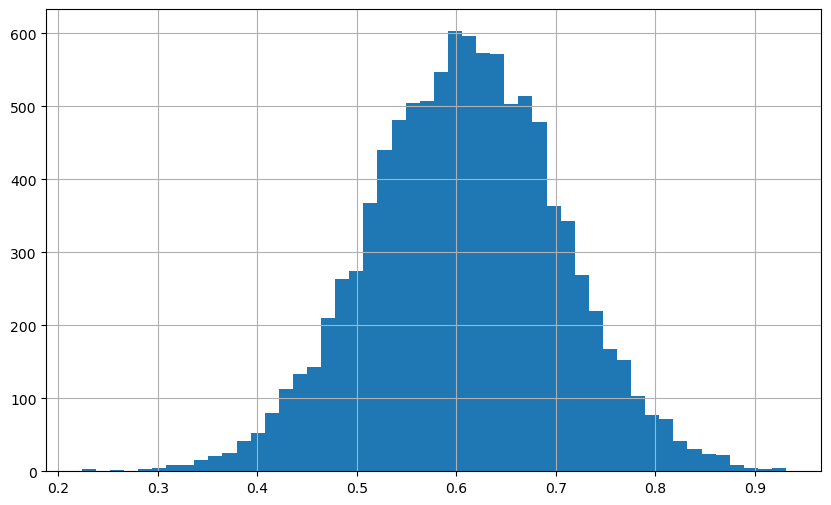

In [22]:
test_scores.hist(
    bins=50,
    figsize=(10, 6)
)

## 18. Run the Monte Carlo Simulation

The Monte Carlo simulation is applied to all projects in the portfolio.

For each project, 100,000 scenarios are generated and summarized using the mean score, standard deviation, minimum score, maximum score, and selected percentiles.

In [23]:
N_PROJECT_SIMULATIONS = 100_000

monte_carlo_results = []

for index, project in df.iterrows():

    scores = simulate_project_score(
        project=project,
        criteria_stats=criterion_stats,
        weights=ahp_weights,
        objectives=criteria_objectives,
        n_simulations=N_PROJECT_SIMULATIONS
    )

    monte_carlo_results.append({
        "Project_ID": project["Project_ID"],
        "MC_Mean": scores.mean(),
        "MC_Std": scores.std(),
        "MC_Min": scores.min(),
        "MC_Max": scores.max(),
        "MC_P05": np.percentile(scores, 5),
        "MC_P50": np.percentile(scores, 50),
        "MC_P95": np.percentile(scores, 95)
    })

monte_carlo_results = pd.DataFrame(
    monte_carlo_results
)

monte_carlo_results.head()

,Project_ID,MC_Mean,MC_Std,MC_Min,MC_Max,MC_P05,MC_P50,MC_P95
0,PROJ_0001,0.606151,0.096370,0.228803,0.961904,0.446606,0.607029,0.763990
1,PROJ_0002,0.758416,0.082425,0.355616,0.995972,0.619924,0.759986,0.891711
2,PROJ_0003,0.840182,0.078195,0.395248,0.999852,0.696236,0.850572,0.951030
3,PROJ_0004,0.593767,0.090048,0.218263,0.924522,0.447713,0.592475,0.743746
4,PROJ_0005,0.655497,0.092735,0.247082,0.950321,0.497217,0.659433,0.801915


## 19. Run the Full Portfolio Simulation

The Monte Carlo simulation is now applied to the complete project portfolio.

For each project, 100,000 scenarios are generated and summarized using descriptive statistics and percentiles.

In [24]:
N_PROJECT_SIMULATIONS = 100_000

monte_carlo_results = []

for index, project in df.iterrows():

    scores = simulate_project_score(
        project=project,
        criteria_stats=criterion_stats,
        weights=ahp_weights,
        objectives=criteria_objectives,
        n_simulations=N_PROJECT_SIMULATIONS
    )

    monte_carlo_results.append({
        "Project_ID": project["Project_ID"],
        "MC_Mean": scores.mean(),
        "MC_Std": scores.std(),
        "MC_Min": scores.min(),
        "MC_Max": scores.max(),
        "MC_P05": np.percentile(scores, 5),
        "MC_P50": np.percentile(scores, 50),
        "MC_P95": np.percentile(scores, 95)
    })

monte_carlo_results = pd.DataFrame(
    monte_carlo_results
)

monte_carlo_results.head()

,Project_ID,MC_Mean,MC_Std,MC_Min,MC_Max,MC_P05,MC_P50,MC_P95
0,PROJ_0001,0.606973,0.096178,0.172187,0.958394,0.448051,0.607749,0.764560
1,PROJ_0002,0.757771,0.082457,0.405497,1.000000,0.619020,0.759191,0.891251
2,PROJ_0003,0.840405,0.078254,0.461184,1.000000,0.695865,0.850930,0.950855
3,PROJ_0004,0.594290,0.090153,0.258382,0.925903,0.447338,0.593289,0.744252
4,PROJ_0005,0.655374,0.092248,0.258463,0.966131,0.498094,0.658682,0.801274


In [25]:
monte_carlo_results.shape

(4000, 8)

In [26]:
monte_carlo_results.describe()

,MC_Mean,MC_Std,MC_Min,MC_Max,MC_P05,MC_P50,MC_P95
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.644675,0.086710,0.256879,0.943182,0.498205,0.647028,0.783601
std,0.094751,0.009135,0.084390,0.058829,0.093048,0.097728,0.089059
min,0.289633,0.047060,0.016124,0.561156,0.185473,0.281132,0.405526
25%,0.583307,0.081239,0.198304,0.922531,0.435629,0.583114,0.731942
50%,0.650020,0.087459,0.253103,0.960827,0.499542,0.652011,0.794604
75%,0.714287,0.092332,0.312294,0.984529,0.566567,0.718260,0.849514
max,0.899162,0.112467,0.508840,1.000000,0.767684,0.913329,0.985095


## 20. Create the Monte Carlo Ranking

Projects are ranked according to their expected score under uncertainty.

The mean Monte Carlo score represents the expected performance of each project across the simulated scenarios.

In [27]:
monte_carlo_ranking = monte_carlo_results.copy()

monte_carlo_ranking = monte_carlo_ranking.sort_values(
    by="MC_Mean",
    ascending=False
).reset_index(drop=True)

monte_carlo_ranking["MC_Rank"] = (
    monte_carlo_ranking.index + 1
)

monte_carlo_ranking.head(20)

,Project_ID,MC_Mean,MC_Std,MC_Min,MC_Max,MC_P05,MC_P50,MC_P95,MC_Rank
0,PROJ_0614,0.899162,0.067527,0.474232,1.000000,0.767684,0.913329,0.984689,1
1,PROJ_1686,0.891604,0.072260,0.508686,1.000000,0.754343,0.904913,0.985095,2
2,PROJ_3497,0.888904,0.068610,0.477808,1.000000,0.756694,0.902654,0.976561,3
3,PROJ_2031,0.887733,0.069666,0.508840,1.000000,0.753177,0.901902,0.977941,4
4,PROJ_0940,0.885036,0.067031,0.465636,1.000000,0.754435,0.898646,0.971103,5
5,PROJ_2845,0.873105,0.073066,0.498072,1.000000,0.735643,0.885651,0.969763,6
6,PROJ_3982,0.869566,0.071762,0.482095,1.000000,0.733102,0.882791,0.963797,7
7,PROJ_1070,0.867142,0.073486,0.444979,1.000000,0.728975,0.879510,0.965137,8
8,PROJ_0434,0.866091,0.074292,0.460383,1.000000,0.728440,0.876998,0.966744,9
9,PROJ_2435,0.865201,0.072576,0.489379,0.999485,0.728730,0.877960,0.961228,10


## 21. Compare AHP and Monte Carlo Rankings

The Monte Carlo ranking is compared with the deterministic AHP ranking to evaluate whether the prioritization remains consistent when uncertainty is introduced.

In [28]:
ahp_ranking = pd.read_csv(
    "../data/processed/ahp_ranking.csv"
)

ahp_ranking["AHP_Rank"] = (
    ahp_ranking["AHP_Score"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

ahp_ranking.head()

,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level,AHP_Score,AHP_Rank
0,PROJ_0614,Manufacturing,3,265992.55,4,1.91,3,Hybrid,Senior,5,...,Basic,Basic,Fully Remote,Good,11,1,1.0,High,0.948052,1
1,PROJ_3497,Manufacturing,9,388789.62,5,2.44,8,Waterfall,Senior,5,...,Basic,NaN,Fully Remote,Basic,8,1,1.0,Medium,0.937929,2
2,PROJ_1686,Healthcare,2,428345.18,4,1.89,7,Scrum,Junior,1,...,Formal,Basic,Hybrid,Excellent,8,1,1.0,Medium,0.935575,3
3,PROJ_0940,Healthcare,4,491707.71,4,2.04,6,Scrum,Mixed,2,...,Formal,NaN,Fully Colocated,Good,12,1,1.0,Low,0.932549,4
4,PROJ_2031,Manufacturing,2,310468.99,3,1.67,4,Kanban,Junior,1,...,Formal,Advanced,Fully Remote,Basic,7,1,1.0,Low,0.930085,5


In [29]:
comparison = ahp_ranking.merge(
    monte_carlo_ranking[
        [
            "Project_ID",
            "MC_Mean",
            "MC_Std",
            "MC_P05",
            "MC_P50",
            "MC_P95",
            "MC_Rank"
        ]
    ],
    on="Project_ID"
)

comparison = comparison.sort_values(
    by="AHP_Rank"
).reset_index(drop=True)

comparison.head(20)

,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Seasonal_Risk_Factor,Risk_Level,AHP_Score,AHP_Rank,MC_Mean,MC_Std,MC_P05,MC_P50,MC_P95,MC_Rank
0,PROJ_0614,Manufacturing,3,265992.55,4,1.91,3,Hybrid,Senior,5,...,1.0,High,0.948052,1,0.899162,0.067527,0.767684,0.913329,0.984689,1
1,PROJ_3497,Manufacturing,9,388789.62,5,2.44,8,Waterfall,Senior,5,...,1.0,Medium,0.937929,2,0.888904,0.068610,0.756694,0.902654,0.976561,3
2,PROJ_1686,Healthcare,2,428345.18,4,1.89,7,Scrum,Junior,1,...,1.0,Medium,0.935575,3,0.891604,0.072260,0.754343,0.904913,0.985095,2
3,PROJ_0940,Healthcare,4,491707.71,4,2.04,6,Scrum,Mixed,2,...,1.0,Low,0.932549,4,0.885036,0.067031,0.754435,0.898646,0.971103,5
4,PROJ_2031,Manufacturing,2,310468.99,3,1.67,4,Kanban,Junior,1,...,1.0,Low,0.930085,5,0.887733,0.069666,0.753177,0.901902,0.977941,4
5,PROJ_3982,Manufacturing,9,623104.86,8,3.02,7,Hybrid,Mixed,0,...,1.0,High,0.920823,6,0.869566,0.071762,0.733102,0.882791,0.963797,7
6,PROJ_2845,Manufacturing,8,647088.67,6,2.65,10,Kanban,Mixed,3,...,1.0,Medium,0.918382,7,0.873105,0.073066,0.735643,0.885651,0.969763,6
7,PROJ_1070,Manufacturing,6,331644.10,8,3.05,3,Hybrid,Mixed,1,...,1.0,High,0.914523,8,0.867142,0.073486,0.728975,0.879510,0.965137,8
8,PROJ_2119,Healthcare,5,287879.33,6,2.11,6,Scrum,Expert,4,...,1.0,Low,0.913478,9,0.865159,0.073521,0.725787,0.877283,0.964705,11
9,PROJ_2068,Manufacturing,7,591695.70,7,1.64,4,Hybrid,Junior,2,...,1.0,Low,0.913064,10,0.862881,0.062957,0.736401,0.878916,0.938650,14


## 22. Measure Ranking Correlation

Spearman's rank correlation is used to measure the degree of agreement between the AHP and Monte Carlo rankings.

In [30]:
spearman_correlation = comparison[
    ["AHP_Rank", "MC_Rank"]
].corr(
    method="spearman"
).iloc[0, 1]

print(
    f"Spearman rank correlation: "
    f"{spearman_correlation:.4f}"
)

Spearman rank correlation: 0.9957


## 23. Compare the Top Projects

The highest-ranked projects from the AHP and Monte Carlo approaches are compared to assess the consistency of the prioritization.

In [31]:
most_stable = comparison.sort_values(
    by="MC_Std",
    ascending=True
)

most_stable[
    [
        "Project_ID",
        "AHP_Rank",
        "MC_Rank",
        "MC_Mean",
        "MC_Std"
    ]
].head(20)

,Project_ID,AHP_Rank,MC_Rank,MC_Mean,MC_Std
3239,PROJ_2348,3240,3411,0.545852,0.047060
3732,PROJ_3027,3733,3781,0.480880,0.047395
2959,PROJ_2235,2960,3022,0.582267,0.049560
2372,PROJ_3371,2373,2415,0.623194,0.050694
3345,PROJ_0145,3346,3574,0.524627,0.051331
3036,PROJ_1342,3037,3217,0.565216,0.053199
2494,PROJ_0941,2495,2548,0.614758,0.053997
3168,PROJ_0757,3169,3466,0.538393,0.054099
2797,PROJ_1509,2798,3064,0.578575,0.054972
1694,PROJ_2536,1695,1856,0.658421,0.055554


In [32]:
most_uncertain = comparison.sort_values(
    by="MC_Std",
    ascending=False
)

most_uncertain[
    [
        "Project_ID",
        "AHP_Rank",
        "MC_Rank",
        "MC_Mean",
        "MC_Std"
    ]
].head(20)

,Project_ID,AHP_Rank,MC_Rank,MC_Mean,MC_Std
3769,PROJ_3588,3770,3703,0.498817,0.112467
3376,PROJ_2797,3377,3222,0.564595,0.111961
3922,PROJ_1116,3923,3831,0.466190,0.111693
3822,PROJ_3003,3823,3678,0.503942,0.111029
3210,PROJ_0682,3211,3184,0.568554,0.110939
3713,PROJ_2984,3714,3682,0.503508,0.110679
2743,PROJ_3317,2744,2807,0.597932,0.110368
3056,PROJ_2314,3057,3061,0.578754,0.110196
3403,PROJ_0355,3404,3245,0.562354,0.110089
3087,PROJ_0457,3088,3156,0.570874,0.109961


## 24. Calculate Rank Difference

The difference between the AHP and Monte Carlo rankings is calculated to identify projects whose prioritization is most affected by uncertainty.

In [33]:
top_20_comparison = comparison[
    [
        "Project_ID",
        "AHP_Rank",
        "AHP_Score",
        "MC_Rank",
        "MC_Mean",
        "MC_Std"
    ]
].sort_values(
    by="AHP_Rank"
)

top_20_comparison.head(20)

,Project_ID,AHP_Rank,AHP_Score,MC_Rank,MC_Mean,MC_Std
0,PROJ_0614,1,0.948052,1,0.899162,0.067527
1,PROJ_3497,2,0.937929,3,0.888904,0.068610
2,PROJ_1686,3,0.935575,2,0.891604,0.072260
3,PROJ_0940,4,0.932549,5,0.885036,0.067031
4,PROJ_2031,5,0.930085,4,0.887733,0.069666
5,PROJ_3982,6,0.920823,7,0.869566,0.071762
6,PROJ_2845,7,0.918382,6,0.873105,0.073066
7,PROJ_1070,8,0.914523,8,0.867142,0.073486
8,PROJ_2119,9,0.913478,11,0.865159,0.073521
9,PROJ_2068,10,0.913064,14,0.862881,0.062957


## 25. Identify the Most Stable Projects

Projects with high expected scores and low score variability are considered more stable candidates for prioritization.

In [34]:
stable_projects = comparison.sort_values(
    by=["MC_Mean", "MC_Std"],
    ascending=[False, True]
)

stable_projects[
    [
        "Project_ID",
        "AHP_Rank",
        "MC_Rank",
        "MC_Mean",
        "MC_Std",
        "MC_P05",
        "MC_P95"
    ]
].head(20)

,Project_ID,AHP_Rank,MC_Rank,MC_Mean,MC_Std,MC_P05,MC_P95
0,PROJ_0614,1,1,0.899162,0.067527,0.767684,0.984689
2,PROJ_1686,3,2,0.891604,0.072260,0.754343,0.985095
1,PROJ_3497,2,3,0.888904,0.068610,0.756694,0.976561
4,PROJ_2031,5,4,0.887733,0.069666,0.753177,0.977941
3,PROJ_0940,4,5,0.885036,0.067031,0.754435,0.971103
6,PROJ_2845,7,6,0.873105,0.073066,0.735643,0.969763
5,PROJ_3982,6,7,0.869566,0.071762,0.733102,0.963797
7,PROJ_1070,8,8,0.867142,0.073486,0.728975,0.965137
18,PROJ_0434,19,9,0.866091,0.074292,0.728440,0.966744
10,PROJ_2435,11,10,0.865201,0.072576,0.728730,0.961228


## 26. Save the Monte Carlo Results

The Monte Carlo results and the comparison with the AHP ranking are saved for further analysis.

In [35]:
Path("../data/processed").mkdir(
    parents=True,
    exist_ok=True
)

monte_carlo_ranking.to_csv(
    "../data/processed/monte_carlo_ranking.csv",
    index=False
)

comparison.to_csv(
    "../data/processed/ahp_monte_carlo_comparison.csv",
    index=False
)

print("Monte Carlo results saved successfully.")

Monte Carlo results saved successfully.


In [36]:
print(
    f"Spearman rank correlation: "
    f"{spearman_correlation:.4f}"
)

Spearman rank correlation: 0.9957


## 27. Visualize the Monte Carlo Score Distribution

The distribution of simulated scores is analyzed to illustrate the uncertainty associated with project prioritization.

<Axes: >

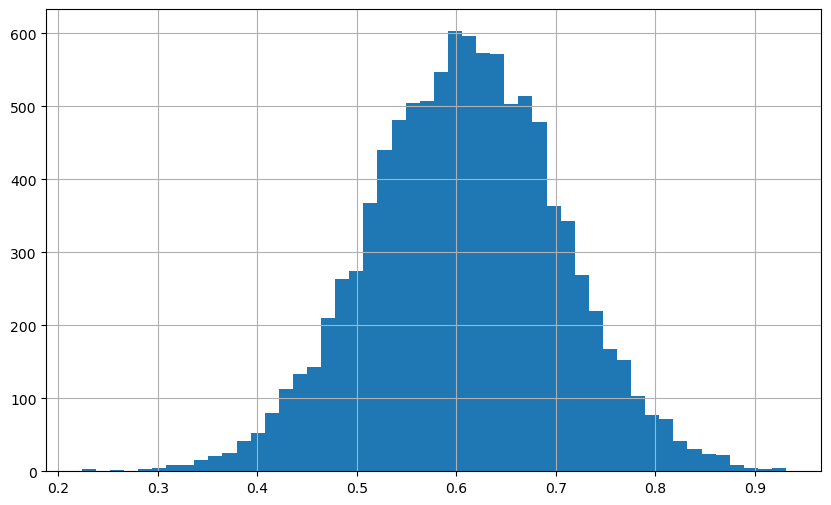

In [37]:
test_scores.hist(
    bins=50,
    figsize=(10, 6)
)

## 28. Compare AHP and Monte Carlo Scores

The deterministic AHP scores are compared with the expected scores obtained from the Monte Carlo simulation.

In [38]:
comparison[
    [
        "Project_ID",
        "AHP_Score",
        "MC_Mean"
    ]
].head(20)

,Project_ID,AHP_Score,MC_Mean
0,PROJ_0614,0.948052,0.899162
1,PROJ_3497,0.937929,0.888904
2,PROJ_1686,0.935575,0.891604
3,PROJ_0940,0.932549,0.885036
4,PROJ_2031,0.930085,0.887733
5,PROJ_3982,0.920823,0.869566
6,PROJ_2845,0.918382,0.873105
7,PROJ_1070,0.914523,0.867142
8,PROJ_2119,0.913478,0.865159
9,PROJ_2068,0.913064,0.862881


In [39]:
score_correlation = comparison[
    ["AHP_Score", "MC_Mean"]
].corr().iloc[0, 1]

print(
    f"Score correlation: "
    f"{score_correlation:.4f}"
)

Score correlation: 0.9948


## 29. Analyze the Most Significant Rank Changes

The projects with the largest differences between their AHP and Monte Carlo rankings are identified to assess the impact of uncertainty on prioritization.

In [40]:
comparison["Rank_Difference"] = (
    comparison["MC_Rank"]
    - comparison["AHP_Rank"]
)

comparison["Absolute_Rank_Difference"] = (
    comparison["Rank_Difference"]
    .abs()
)

In [41]:
largest_rank_changes = comparison.sort_values(
    by="Absolute_Rank_Difference",
    ascending=False
)

largest_rank_changes[
    [
        "Project_ID",
        "AHP_Rank",
        "MC_Rank",
        "Rank_Difference",
        "AHP_Score",
        "MC_Mean",
        "MC_Std"
    ]
].head(20)

,Project_ID,AHP_Rank,MC_Rank,Rank_Difference,AHP_Score,MC_Mean,MC_Std
2150,PROJ_3295,2151,1672,-479,0.645344,0.669525,0.104817
2577,PROJ_0668,2578,2153,-425,0.612561,0.640783,0.108430
2089,PROJ_2247,2090,1673,-417,0.649628,0.669429,0.107169
2352,PROJ_1538,2353,1967,-386,0.628908,0.651609,0.095839
3095,PROJ_2545,3096,2711,-385,0.569706,0.603979,0.092785
951,PROJ_1619,952,1325,373,0.733197,0.692843,0.079596
2567,PROJ_3180,2568,2930,362,0.612883,0.588579,0.078910
897,PROJ_0695,898,1259,361,0.737311,0.697597,0.097051
2278,PROJ_3183,2279,2638,359,0.635200,0.608326,0.092810
595,PROJ_0737,596,953,357,0.762375,0.717431,0.095572


## 30. Identify Robust Top Projects

Projects that remain among the top-ranked alternatives across both AHP and Monte Carlo are considered robust candidates for prioritization.

In [42]:
comparison["AHP_Top_20"] = (
    comparison["AHP_Rank"] <= 20
)

comparison["MC_Top_20"] = (
    comparison["MC_Rank"] <= 20
)

robust_top_projects = comparison[
    comparison["AHP_Top_20"]
    & comparison["MC_Top_20"]
].sort_values(
    by="AHP_Rank"
)

robust_top_projects[
    [
        "Project_ID",
        "AHP_Rank",
        "MC_Rank",
        "AHP_Score",
        "MC_Mean",
        "MC_Std"
    ]
]

,Project_ID,AHP_Rank,MC_Rank,AHP_Score,MC_Mean,MC_Std
0,PROJ_0614,1,1,0.948052,0.899162,0.067527
1,PROJ_3497,2,3,0.937929,0.888904,0.068610
2,PROJ_1686,3,2,0.935575,0.891604,0.072260
3,PROJ_0940,4,5,0.932549,0.885036,0.067031
4,PROJ_2031,5,4,0.930085,0.887733,0.069666
5,PROJ_3982,6,7,0.920823,0.869566,0.071762
6,PROJ_2845,7,6,0.918382,0.873105,0.073066
7,PROJ_1070,8,8,0.914523,0.867142,0.073486
8,PROJ_2119,9,11,0.913478,0.865159,0.073521
9,PROJ_2068,10,14,0.913064,0.862881,0.062957


## 31. Calculate Top-20 Ranking Overlap

The overlap between the AHP and Monte Carlo top-20 rankings is calculated as a measure of prioritization stability.

In [43]:
top_20_overlap = len(robust_top_projects)

overlap_percentage = (
    top_20_overlap / 20
) * 100

print(
    f"Top-20 overlap: "
    f"{top_20_overlap}/20 "
    f"({overlap_percentage:.1f}%)"
)

Top-20 overlap: 16/20 (80.0%)


## 32. Save the Final Monte Carlo Outputs

The final Monte Carlo ranking and the AHP-Monte Carlo comparison are saved as processed datasets for subsequent analysis.

In [44]:
monte_carlo_ranking.to_csv(
    "../data/processed/monte_carlo_ranking.csv",
    index=False
)

comparison.to_csv(
    "../data/processed/ahp_monte_carlo_comparison.csv",
    index=False
)

print("Final Monte Carlo outputs saved successfully.")

Final Monte Carlo outputs saved successfully.


## 33. Summary

The Monte Carlo simulation introduced uncertainty into the project evaluation criteria and generated 100,000 scenarios for each project.

The results provide:

- Expected project scores under uncertainty
- Score variability for each project
- Confidence ranges based on simulated percentiles
- Monte Carlo project rankings
- Comparison between deterministic AHP and Monte Carlo rankings
- Identification of robust projects that remain highly ranked under uncertainty

These results will be used in the subsequent analysis to evaluate the robustness of project portfolio prioritization.